# **Complete repository step-by-step diagnostics. (Simulation Modules)**

Speed values in this repo are km/h, and one simulation tick equals one second.

In [1]:
import yaml
from typing import Any, Callable, Optional
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph
from IPython.display import Image as IPyImage, display
from rich import print 

def assert_true(condition: bool, message: str) -> bool:
    if not condition: raise AssertionError(message)
    return True

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result


In [2]:
import os
from dotenv import load_dotenv
import yaml
from utils.city_graph import CityGraph
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig
from utils.route import RouteGenerator
from utils.travel_graph import TravelGraph

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

# Load configurations and instantiate baseline components.
# Speed values used later are km/h, and one update tick equals one second.
with open('configs/iligan_configs.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

city_graph_cfg = cfg["city_graph"]
city = CityGraph(
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg["landmarks"],
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    verbose=True
)

sampler = DirectDemandSampler(
    city=city,
    config=DDMConfig(**cfg["ddm"]),
    only_drivable=True
)

generator = RouteGenerator(
    city_graph=city,
    sampler=sampler
)

tg = TravelGraph(
    cg=city,
    route_generator=generator,
    config=cfg["travel_graph"],
    n_routes=20,
    n_points=5
)


[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 128870.41it/s]


## **Jeep System** (in jeep.py and jeep_system.py)

[VALIDATED] Generate demo route: Executed successfully.

[VALIDATED] Spawn jeep on route: Executed successfully.

Target node count for full loop: 2665

[REJECTED] Jeep failed to complete loop within an hour of simulation time.

[VALIDATED] Compile single jeep loop GIF: Executed successfully.

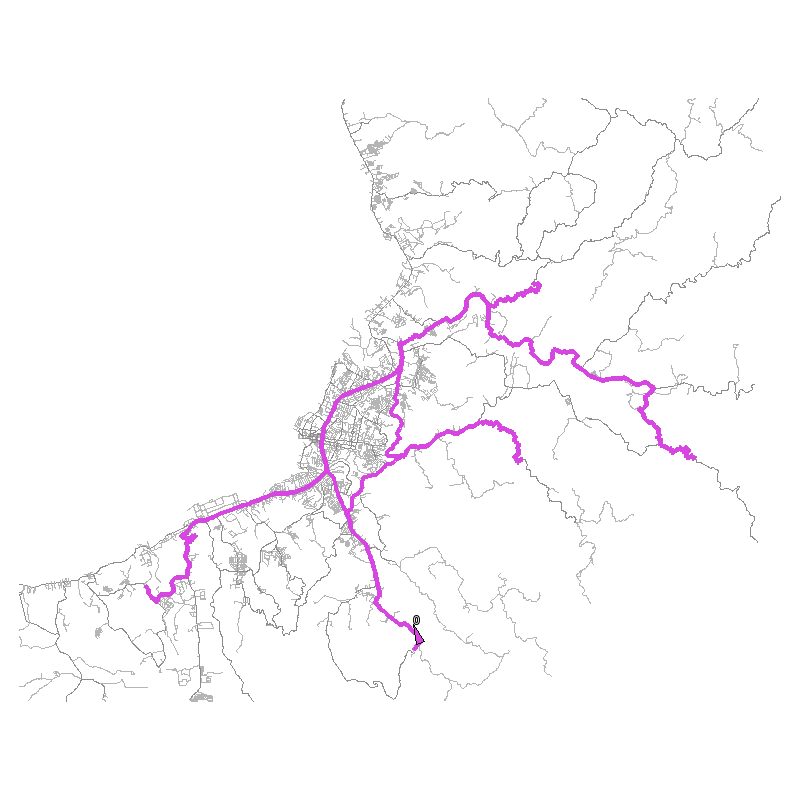

In [ ]:
# Single Jeep Traversal & Visualization

from utils.jeep import Jeep
from utils.visualization import compile_to_gif
from IPython.display import Image as IPyImage, display
from PIL import Image

# 1. Generate Route & Initialize Jeep
demo_route = validate_call(
    "Generate demo route",
    True,
    generator.generate,
    n_points=5
)

start_node = demo_route.path[0].start
jeep = validate_call(
    "Spawn jeep on route",
    True,
    Jeep,
    demo_route,
    (start_node.lon, start_node.lat),
    60.0 # 60 km/h
)

# 2. Track Expected Nodes
expected_node_ids = {edge.start.id for edge in demo_route.path}
traversed_node_ids = set()
print(f"Target node count for full loop: {len(expected_node_ids)}")

# 3. Simulate and Render
context = city.get_bounds()
frames = []
tick = 0
base_map = city.draw(size=800)

while True:
    jeep.update()
    tick += 1
    
    # Track node traversal
    passed_nodes = jeep.nodes_passed_this_frame() or []
    for node, _ in passed_nodes:
        traversed_node_ids.add(node.id)
        
    # Render frame
    if tick % 30 == 0:
        frame = demo_route.draw(context, base_map.copy(), width=4)
        frame = jeep.draw(context, frame, radius=12)
        frames.append(frame)

    # Break condition: All required nodes have been traversed in one loop
    if traversed_node_ids == expected_node_ids:
        print(f"Successfully traversed all {len(expected_node_ids)} nodes in {tick} ticks.")
        break
    
    # Failsafe
    if tick > 10000:
        print("[REJECTED] Jeep failed to complete loop within an hour of simulation time.")
        break

gif_bytes = validate_call(
    "Compile single jeep loop GIF",
    True,
    compile_to_gif,
    frames,
    6,
    export_to="utils/.cache/jeep_route_loop.gif"
)
if gif_bytes:
    display(IPyImage(data=gif_bytes, format="gif"))

[VALIDATED] Initialize JeepSystem: Executed successfully.

Running JeepSystem simulation for 300 ticks...

Simulation capped at 300 ticks.

[VALIDATED] Compile JeepSystem GIF: Executed successfully.

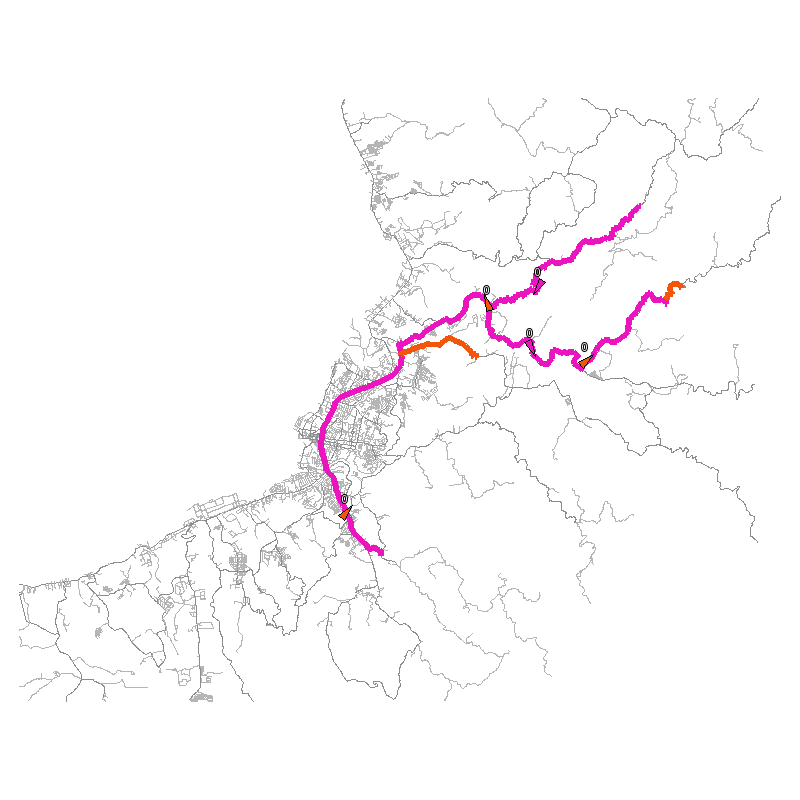

In [4]:
# Jeep System Multi-Route Simulation

from utils.jeep_system import JeepSystem
from utils.route import RouteSystem
from IPython.display import Image as IPyImage, display

# 1. Setup Multiple Routes
rs = RouteSystem()
route_A = generator.generate(n_points=4)
route_B = generator.generate(n_points=5)
rs.add_route(route_A)
rs.add_route(route_B)

# 2. Spawn Fleet
fleet = []
# 3 Jeeps on Route A
for _ in range(3):
    start = route_A.path[0].start
    fleet.append(Jeep(route_A, (start.lon, start.lat), speed=45.0))

# 2 Jeeps on Route B
for _ in range(2):
    start = route_B.path[0].start
    fleet.append(Jeep(route_B, (start.lon, start.lat), speed=50.0))

system = validate_call(
    "Initialize JeepSystem",
    True,
    JeepSystem,
    jeeps=fleet,
    routes=[route_A, route_B],
    weight_tolerance=50.0
)

# 3. Simulate with Tick Cap
system_frames = []
TICK_CAP = 300

# Fix applied here: Enforce exact method signatures and context extraction.
context = city.get_bounds()
base_map = city.draw(size=800)

# Pre-draw routes onto the base map using RouteSystem's dashed renderer
base_map = rs.draw(context, base_map, line_width=6, dash_length=15)

print(f"Running JeepSystem simulation for {TICK_CAP} ticks...")

for tick in range(TICK_CAP):
    system.update()
    
    if tick % 5 == 0:
        frame = base_map.copy()
        frame = system.draw(context, frame, radius=10)
        system_frames.append(frame)

print(f"Simulation capped at {TICK_CAP} ticks.")

sys_gif_bytes = validate_call(
    "Compile JeepSystem GIF",
    True,
    compile_to_gif,
    system_frames,
    10,
    export_to="utils/.cache/jeep_system_demo.gif"
)
if sys_gif_bytes:
    display(IPyImage(data=sys_gif_bytes, format="gif"))